<a href="https://colab.research.google.com/github/nicholas-schwier-class/Computational-Probability-and-Stats-2026/blob/main/Ch4_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Uniform Distribution Example

Suppose a bus arrives randomly and uniformly between
7:00 AM and 7:20 AM.

That means:

Every minute between 0 and 20 minutes after 7:00 AM is equally likely.

This follows a Uniform(0, 20) distribution (measured in minutes).

Mean arrival time = 10 minutes after 7:00 AM (7:10 AM)

2. Exponential Distribution Example

Suppose a coffee shop observes that, on average,
3 customers arrive per minute.

When events happen:

Randomly

Independently

At a constant average rate

The waiting time between arrivals follows an Exponential distribution.

3. Gamma Distribution

The Gamma distribution is commonly used to model:

Waiting time until the k-th event

*   Service times
*   Rainfall amounts

It has two parameters:

shape (k) – number of events

scale (θ) – average time between events

Mean =
𝑘
𝜃


Variance =
𝑘
𝜃
2


4. Normal Distribution Example
Heights of adult males in many populations are approximately normally distributed.

We’ll use a commonly cited real-world summary:

Mean height ≈ 175 cm

Standard deviation ≈ 7 cm

We will:

Simulate a realistic dataset of heights

Plot the data

Overlay the theoretical Normal curve

Compute real probabilities

Suppose we collect exam scores from 100 students and want to check if the distribution is approximately normal.

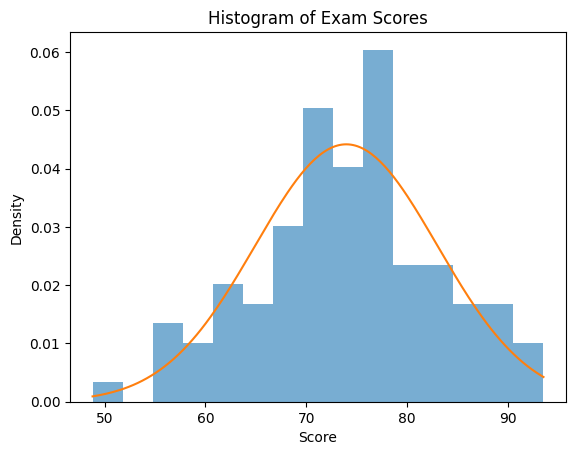

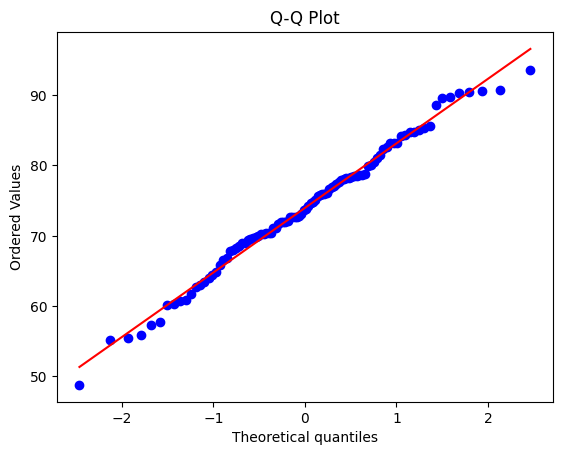

Shapiro-Wilk Test Statistic: 0.9898833815158516
p-value: 0.6551676754214818
Data looks approximately normal (fail to reject H0).
Skewness: -0.17526772024433837
Kurtosis: -0.15540470774207993


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------
# Generate example data
# (Normally distributed scores)
# -----------------------------
np.random.seed(42)
scores = np.random.normal(loc=75, scale=10, size=100)

# -----------------------------
# 1. Histogram
# -----------------------------
plt.hist(scores, bins=15, density=True, alpha=0.6)

x = np.linspace(min(scores), max(scores), 200)
plt.plot(x, stats.norm.pdf(x, np.mean(scores), np.std(scores)))

plt.title("Histogram of Exam Scores")
plt.xlabel("Score")
plt.ylabel("Density")
plt.show()

# -----------------------------
# 2. Q-Q Plot
# -----------------------------
stats.probplot(scores, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

# -----------------------------
# 3. Shapiro-Wilk Test
# -----------------------------
stat, p_value = stats.shapiro(scores)

print("Shapiro-Wilk Test Statistic:", stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("Data looks approximately normal (fail to reject H0).")
else:
    print("Data is NOT normal (reject H0).")

# -----------------------------
# 4. Skewness and Kurtosis
# -----------------------------
print("Skewness:", stats.skew(scores))
print("Kurtosis:", stats.kurtosis(scores))

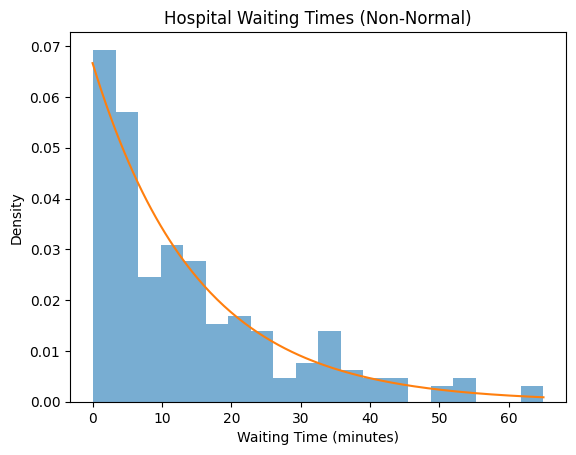

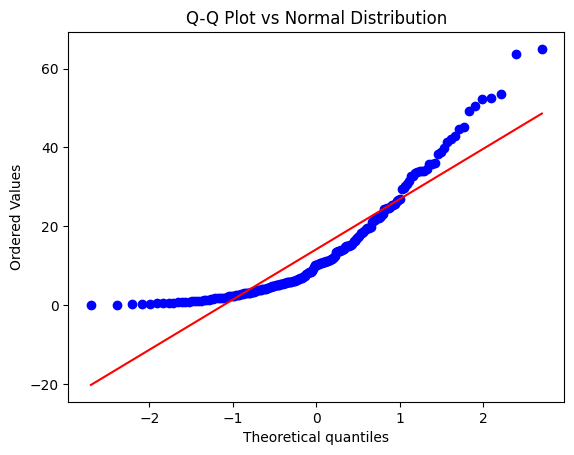

Shapiro-Wilk p-value: 5.532478172231605e-13
Data is NOT normal.
Skewness: 1.3663300866716612


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------
# Simulate real-world waiting times
# -----------------------------
np.random.seed(42)
waiting_times = np.random.exponential(scale=15, size=200)
# scale = 15 minutes average waiting time

# -----------------------------
# Histogram
# -----------------------------
plt.hist(waiting_times, bins=20, density=True, alpha=0.6)

x = np.linspace(0, max(waiting_times), 200)
plt.plot(x, stats.expon.pdf(x, scale=15))

plt.title("Hospital Waiting Times (Non-Normal)")
plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Density")
plt.show()

# -----------------------------
# Q-Q Plot against Normal
# -----------------------------
stats.probplot(waiting_times, dist="norm", plot=plt)
plt.title("Q-Q Plot vs Normal Distribution")
plt.show()

# -----------------------------
# Shapiro-Wilk Test
# -----------------------------
stat, p_value = stats.shapiro(waiting_times)

print("Shapiro-Wilk p-value:", p_value)

if p_value > 0.05:
    print("Data looks approximately normal.")
else:
    print("Data is NOT normal.")

# -----------------------------
# Skewness
# -----------------------------
print("Skewness:", stats.skew(waiting_times))